# Week 7: Live Session - Deep Learning Best Practices

**Topics:** Three-way Split, Overfitting Diagnosis, Dropout, EarlyStopping  
**Scaffolding:** 60% provided (follow-along coding)  
**Format:** Instructor-led with student execution

---

## Session Outline

1. Three-way data split (train/val/test)
2. Overfitting diagnosis with training curves
3. Dropout regularization
4. EarlyStopping callback
5. Complete Fashion-MNIST pipeline

---

## Setup

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(f"Keras version: {keras.__version__}")
print("Setup complete!")

Keras version: 3.13.2
Setup complete!


---

## Part 1: Load Fashion-MNIST

In [2]:
# Load Fashion-MNIST dataset
from keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(f"Full training set: {X_train_full.shape}")
print(f"Test set: {X_test.shape}")

Full training set: (60000, 28, 28)
Test set: (10000, 28, 28)


In [3]:
# Normalize to 0-1 range
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

print("Data normalized")

Data normalized


---

## Part 2: Three-Way Split (NEW!)

**Week 6:** Train/Test split (2 sets)  
**Week 7:** Train/Validation/Test split (3 sets)

- **Training:** Update weights
- **Validation:** Monitor overfitting during training
- **Test:** Final evaluation (touch ONCE at the end)

In [4]:
# TODO: Split training data into train and validation sets
# Use train_test_split with test_size=0.2 (20% for validation)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Training set: (48000, 28, 28)
Validation set: (12000, 28, 28)
Test set: (10000, 28, 28)


In [5]:
# Flatten all sets for Dense layers
X_train_flat = X_train.reshape(-1, 784)
X_val_flat = X_val.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

print(f"Flattened training: {X_train_flat.shape}")
print(f"Flattened validation: {X_val_flat.shape}")
print(f"Flattened test: {X_test_flat.shape}")

Flattened training: (48000, 784)
Flattened validation: (12000, 784)
Flattened test: (10000, 784)


---

## Part 3: Build Overfitting Model (For Demonstration)

**Goal:** Intentionally create overfitting to see the problem

In [6]:
# Large model WITHOUT regularization (will overfit!)
model_overfit = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_overfit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Overfitting model (NO regularization):")
model_overfit.summary()

Overfitting model (NO regularization):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train overfitting model
print("Training overfitting model...")
history_overfit = model_overfit.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

print("Training complete!")

Training overfitting model...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8159 - loss: 0.5183 - val_accuracy: 0.8497 - val_loss: 0.4183
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8658 - loss: 0.3661 - val_accuracy: 0.8603 - val_loss: 0.3686
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8780 - loss: 0.3313 - val_accuracy: 0.8731 - val_loss: 0.3454
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8884 - loss: 0.3020 - val_accuracy: 0.8739 - val_loss: 0.3481
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8941 - loss: 0.2842 - val_accuracy: 0.8802 - val_loss: 0.3270
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8984 - loss: 0.2696 - val_accuracy: 0.8838 - val_loss: 0.3194
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9028 - loss: 0.2567 - val_accuracy: 0.8876 - val_loss: 0.3121
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9084 - l

### Diagnose Overfitting with Training Curves

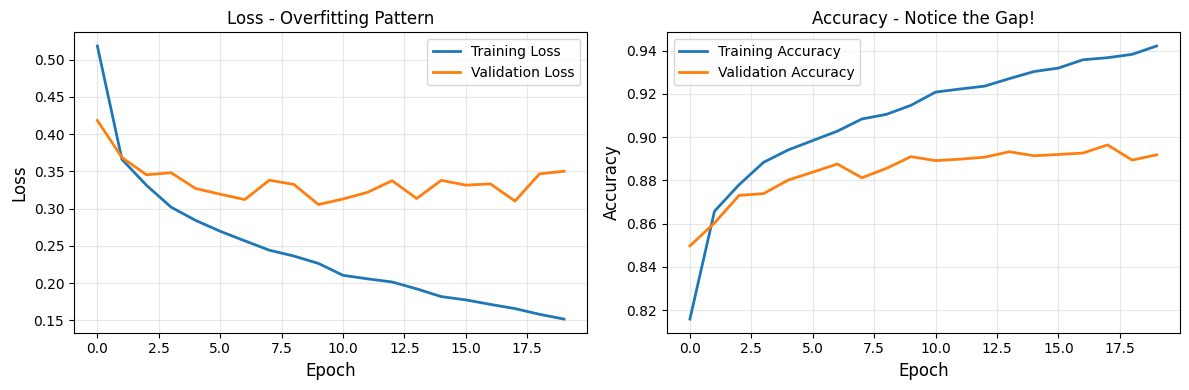


Final Training Accuracy: 0.9422
Final Validation Accuracy: 0.8918
Gap (overfitting): 0.0503


In [8]:
# Plot training curves to diagnose overfitting
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_overfit.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.title('Loss - Overfitting Pattern')
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_overfit.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.title('Accuracy - Notice the Gap!')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final accuracies
train_acc = history_overfit.history['accuracy'][-1]
val_acc = history_overfit.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Gap (overfitting): {(train_acc - val_acc):.4f}")

**Diagnosis:** Training accuracy much higher than validation accuracy = OVERFITTING!

---

## Part 4: Fix Overfitting with Dropout

**Dropout:** Randomly deactivate neurons during training  
**Analogy:** "Network on a Diet" - forces learning of robust features

In [10]:
# TODO: Build model WITH Dropout
# Add Dropout(0.3) after each Dense layer (except output)

model = keras.Sequential([
    layers.Input(shape=(784,)),
    
    layers.Dense(128, activation='relu'),
    # TODO: Add Dropout layer with rate=0.3
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    # TODO: Add Dropout layer with rate=0.3
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')  # NO Dropout before output!
])

print("Model with Dropout:")
model.summary()

Model with Dropout:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

---

## Part 5: Add EarlyStopping Callback

**EarlyStopping:** Automatically stops training when validation loss stops improving  
**Analogy:** "Validation Alarm" - sounds when it's time to stop

In [11]:
from keras.callbacks import EarlyStopping

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Create EarlyStopping callback
# Monitor 'val_loss', patience=5, restore_best_weights=True

early_stop = EarlyStopping(
    monitor='val_loss',        # What metric to watch?
    patience=5,         # How many epochs to wait?
    restore_best_weights=True,  # Restore best epoch?
    verbose=1
)

print("EarlyStopping configured!")

EarlyStopping configured!


---

## Part 6: Train Model with Regularization

In [12]:
# Train with Dropout + EarlyStopping
print("Training model with regularization...")
history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),  # REQUIRED for EarlyStopping!
    epochs=50,  # Set high - EarlyStopping will stop us
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining stopped early!")

Training model with regularization...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7211 - loss: 0.7870 - val_accuracy: 0.8288 - val_loss: 0.4761
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8213 - loss: 0.5049 - val_accuracy: 0.8512 - val_loss: 0.4111
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8383 - loss: 0.4513 - val_accuracy: 0.8569 - val_loss: 0.3826
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8508 - loss: 0.4204 - val_accuracy: 0.8607 - val_loss: 0.3787
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8557 - loss: 0.4022 - val_accuracy: 0.8660 - val_loss: 0.3648
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8604 - loss: 0.3859 - val_accuracy: 0.8742 - val_loss: 0.3461
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8671 - loss: 0.3680 - val_accuracy: 0.8766 - val_loss: 0.3375
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.

### Plot Improved Training Curves

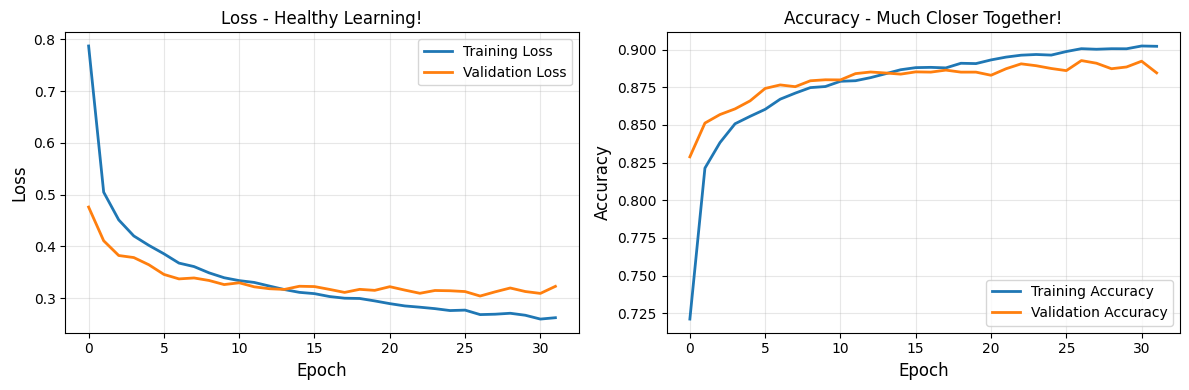


Final Training Accuracy: 0.9022
Final Validation Accuracy: 0.8846
Gap (much smaller!): 0.0176


In [13]:
# Plot training curves - should show healthy learning!
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.title('Loss - Healthy Learning!')
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.title('Accuracy - Much Closer Together!')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final accuracies
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Gap (much smaller!): {(train_acc - val_acc):.4f}")

---

## Part 7: Final Evaluation on Test Set

In [14]:
# Evaluate on test set (FIRST TIME touching test data!)
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Compare to validation
print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {abs(val_acc - test_accuracy):.4f} (should be small!)")

Test Accuracy: 0.8861
Test Loss: 0.3278

Validation Accuracy: 0.8846
Test Accuracy: 0.8861
Difference: 0.0015 (should be small!)


---

## Part 8: Save and Load Model

In [15]:
# Save complete model
model.save('fashion_mnist_model.keras')
print("Model saved to 'fashion_mnist_model.keras'")

# Demonstrate loading
from keras.models import load_model
loaded_model = load_model('fashion_mnist_model.keras')
print("Model loaded successfully!")

# Verify it works
predictions = loaded_model.predict(X_test_flat[:5], verbose=0)
print(f"\nPredictions shape: {predictions.shape}")
print(f"First prediction: class {np.argmax(predictions[0])}")

Model saved to 'fashion_mnist_model.keras'
Model loaded successfully!

Predictions shape: (5, 10)
First prediction: class 9


---

## Summary: Week 7 Best Practices

**What we learned:**

1. **Three-way split:** Train/Validation/Test
   - Train: Update weights
   - Validation: Monitor overfitting
   - Test: Final evaluation

2. **Diagnose overfitting:** Plot training curves
   - Large gap between train/val = overfitting
   - Close curves = healthy learning

3. **Dropout regularization:** Add after Dense layers
   - Rate 0.3 is typical starting point
   - Forces robust feature learning

4. **EarlyStopping callback:** Automatic training control
   - Monitors val_loss
   - Stops when no improvement
   - Restores best weights

5. **Model persistence:** Save and load
   - model.save() for complete model
   - load_model() for reuse

**Production-ready workflow!**

---

*Week 7 Live Session | Version 1.0 | February 2026*